In [4]:
import os
import glob

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns
from scipy.stats import pearsonr, spearmanr, pointbiserialr
from scipy.stats import f_oneway, kruskal

import stackview
from PIL import Image
from sklearn.metrics import r2_score, roc_curve, auc

from zod import ZodFrames
from zod.constants import AnnotationProject, Camera
from zod.visualization.object_visualization import overlay_object_2d_box_on_image

plt.style.use('default')
sns.set_palette("husl")
SEED = 43
np.random.seed(SEED)

# Load Data

In [5]:
base_data_path_file = "faster-rcnn_metafeatures.csv"

iou_assessor_results = pd.read_csv("../results/assessors/iou_test_ass_" + base_data_path_file, index_col=0)
lrp_assessor_results = pd.read_csv("../results/assessors/lrp_test_ass_" + base_data_path_file, index_col=0)

print(iou_assessor_results.head(5))


     country time_of_day        lat       long       road_type road_condition  \
5799      IT         day  43.789268  11.223805  arterial-urban         normal   
4825      DE         day  51.336285  12.362665            city         normal   
5022      DE         day  50.996585   7.040198            city         normal   
3355      IT         day  45.491401   9.245215            city         normal   
4766      PL         day  52.273716  21.064427            city            wet   

                weather  solar_angle_elevation  month  hour  ...  \
5799          clear-day              52.668839      8     9  ...   
4825  partly-cloudy-day              35.226446      9    10  ...   
5022          clear-day              17.898305     11    11  ...   
3355          clear-day              63.519031      7    10  ...   
4766               rain              22.967036      4    14  ...   

      weather_code      conf        GT  baseline        lr        dt  \
5799           1.0  0.780884  0.

In [6]:
dataset_root = "../data/zod"
version = "full" 
zod_frames = ZodFrames(dataset_root=dataset_root, version=version)

Loading infos: 0it [00:00, ?it/s]

# Assessor Performance

In [7]:
def evaluate_regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    errors = y_true - y_pred

    bin_size = 0.1
    bins = np.arange(0.0, 1.0 + bin_size, bin_size)
    bin_ids = np.digitize(y_pred, bins, right=False)

    ece = 0.0
    N = len(y_pred)

    for i in range(1, len(bins)):
        mask = bin_ids == i
        if not np.any(mask):
            continue

        bin_center = (bins[i - 1] + bins[i]) / 2.0
        median_obs = np.median(y_true[mask])
        ece += (mask.sum() / N) * abs(median_obs - bin_center)
        
    return {
        'r2': r2_score(y_true, y_pred),
        'mae': float(np.mean(np.abs(errors))),
        'mse': float(np.mean(errors ** 2)),
        "p95": np.quantile(np.abs(errors), 0.95),
        'ece': float(ece),              # Expected calibration error
    }


def record_regression_results(results, target, model_name, y_true, y_pred, split='test'):
    metrics = evaluate_regression_metrics(y_true, y_pred)
    split_label = split.capitalize()
    print(f"{split_label} R2 score {metrics['r2']:.4f}")
    print(f"{split_label} MAE score {metrics['mae']:.4f}")
    print(f"{split_label} MSE score {metrics['mse']:.4f}")
    print(f"{split_label} P95 score {metrics['p95']:.4f}")
    print(f"{split_label} ECE score {metrics['ece']:.4f}")
    results.append({
        'target': target,
        'model': model_name,
        f'{split}_r2': metrics['r2'],
        f'{split}_mae': metrics['mae'],
        #f'{split}_mse': metrics['mse'],
        #f'{split}_p95': metrics['p95'],
        f'{split}_ece': metrics['ece'],
    })
    return metrics

## IoU

In [8]:
model_cols = ["baseline", "lr", "dt", "rf", "mlp", "xgb", "autg"]

In [9]:
iou_metrics_rows = []
for model in model_cols:
    metrics = evaluate_regression_metrics(iou_assessor_results["GT"], iou_assessor_results[model])
    iou_metrics_rows.append({"model": model, **metrics})

iou_metrics = pd.DataFrame(iou_metrics_rows).sort_values("r2", ascending=False)
display(iou_metrics)


,model,r2,mae,mse,p95,ece
6,autg,0.468022,0.115531,0.023638,0.322062,0.014841
3,rf,0.453632,0.116417,0.024277,0.327845,0.015107
5,xgb,0.440710,0.117875,0.024852,0.334549,0.012284
1,lr,0.426832,0.122328,0.025468,0.326327,0.023339
2,dt,0.424438,0.119404,0.025575,0.335372,0.023170
4,mlp,0.419169,0.122360,0.025809,0.332974,0.039413
0,baseline,0.299188,0.135008,0.031140,0.389282,0.048464


## LRP

In [10]:
lrp_metrics_rows = []
for model in model_cols:
    metrics = evaluate_regression_metrics(lrp_assessor_results["GT"], lrp_assessor_results[model])
    lrp_metrics_rows.append({"model": model, **metrics})

lrp_metrics = pd.DataFrame(lrp_metrics_rows).sort_values("r2", ascending=False)
display(lrp_metrics)


,model,r2,mae,mse,p95,ece
6,autg,0.507130,0.095997,0.017409,0.282067,0.013485
3,rf,0.493010,0.096860,0.017908,0.281752,0.016427
5,xgb,0.476575,0.098293,0.018489,0.298287,0.013528
4,mlp,0.469843,0.099636,0.018726,0.291622,0.021470
2,dt,0.465251,0.099850,0.018889,0.288065,0.019981
1,lr,0.430236,0.105646,0.020126,0.309983,0.025281
0,baseline,0.297331,0.117540,0.024820,0.357548,0.044381


# Error analysis

In [11]:
THRESHOLD = 0.5   # Delta between predicte and expected value
TARGET_MODEL = "autg"

## IoU

In [12]:

error_df = iou_assessor_results.copy()
error_df[f"abs_delta_{TARGET_MODEL}"] = (error_df["GT"] - error_df[TARGET_MODEL]).abs()
error_df[f"delta_{TARGET_MODEL}"] = (error_df["GT"] - error_df[TARGET_MODEL])
high_error = error_df[error_df[f"abs_delta_{TARGET_MODEL}"] > THRESHOLD]

print(f"High-error instances (|GT - {TARGET_MODEL}| > {THRESHOLD}): {len(high_error)}")
display(high_error[["GT", TARGET_MODEL, f"abs_delta_{TARGET_MODEL}", f"delta_{TARGET_MODEL}"]].head(10))

High-error instances (|GT - autg| > 0.5): 28


,GT,autg,abs_delta_autg,delta_autg
7975,0.781605,0.149995,0.631610,0.631610
9395,0.747619,0.175572,0.572047,0.572047
3876,0.868730,0.139574,0.729156,0.729156
9279,0.866556,0.308351,0.558204,0.558204
7837,0.682174,0.159922,0.522252,0.522252
8259,0.047155,0.729498,0.682343,-0.682343
8938,0.243278,0.749134,0.505856,-0.505856
3967,0.744539,0.156996,0.587544,0.587544
7552,0.781055,0.174036,0.607019,0.607019
7644,0.192338,0.702536,0.510198,-0.510198


In [13]:
imgs_good_gt = []
id_good_gt = []
imgs_bad_gt = []
id_bad_gt = []
missing = []
for frame_id in high_error.index:
    zod_frame = zod_frames[frame_id]
    image = zod_frame.get_image() 
    annotations = zod_frame.get_annotation(AnnotationProject.OBJECT_DETECTION)
    annotations_2d = [annotation.box2d for annotation in annotations if annotation.name in ['Vehicle', 'Pedestrian', 'VulnerableVehicle'] and str(annotation.occlusion_level) in ["None", "Medium"] and (annotation.box2d.ymax - annotation.box2d.ymin) >= 25]

    for ann in annotations_2d:
        image_with_boxes = overlay_object_2d_box_on_image(image,ann, color=(255, 0, 0), line_thickness=10)

    if image_with_boxes is None:
        missing.append(frame_id)

    if high_error.loc[frame_id][f"delta_{TARGET_MODEL}"] > 0:
        imgs_good_gt.append(image_with_boxes)
        id_good_gt.append(frame_id)
    else: 
        imgs_bad_gt.append(image_with_boxes)
        id_bad_gt.append(frame_id)

In [14]:
print(f"Number of images: {len(imgs_good_gt) + len(imgs_bad_gt)} with id {high_error.index}")
print(f"Missing images: {len(missing)} with ids: {sorted(missing)}")

Number of images: 28 with id Index([7975, 9395, 3876, 9279, 7837, 8259, 8938, 3967, 7552, 7644, 5789, 7101,
       7403, 6294, 5084, 4440, 4448, 8698, 7274, 5829, 4872, 5644, 8006, 6305,
       9408, 5425, 3047, 6375],
      dtype='int64')
Missing images: 0 with ids: []


Images where object detection system worked well, but assessor predicted it will not

In [15]:
#stack = np.stack(imgs, axis=0)
stack = dict(zip([str(i) for i in id_good_gt], imgs_good_gt))
stackview.switch(stack)

In [16]:
display(iou_assessor_results.loc[id_good_gt])

,country,time_of_day,lat,long,road_type,road_condition,weather,solar_angle_elevation,month,hour,...,weather_code,conf,GT,baseline,lr,dt,rf,mlp,xgb,autg
7975,SE,night,65.590528,22.231899,smaller-rural,snow,cloudy,-10.181969,3,18,...,3.0,0.544780,0.781605,0.176432,0.260148,0.164956,0.221079,0.215629,0.131353,0.149995
9395,PL,day,53.535271,20.275325,smaller-rural,normal,partly-cloudy-day,48.340208,4,11,...,1.0,0.598943,0.747619,0.216976,0.273143,0.264137,0.215042,0.250149,0.189598,0.175572
3876,SE,twilight,59.274127,15.200942,city,normal,partly-cloudy-night,-1.503317,5,19,...,0.0,0.557343,0.868730,0.185836,0.175753,0.164956,0.140089,0.157812,0.110733,0.139574
9279,SE,twilight,67.681874,21.633614,arterial-rural,snow,fog,-3.644680,1,13,...,73.0,0.727911,0.866556,0.313514,0.367648,0.241583,0.256461,0.363441,0.243624,0.308351
7837,SE,day,64.588882,18.667067,smaller-rural,snow,cloudy,17.924592,3,10,...,71.0,0.592406,0.682174,0.212083,0.369556,0.264137,0.177543,0.339120,0.140104,0.159922
3967,SE,day,59.269355,15.240764,city,normal,cloudy,7.421689,5,18,...,2.0,0.556117,0.744539,0.184918,0.247921,0.264137,0.188472,0.234028,0.170816,0.156996
7552,PL,day,50.252009,19.825218,smaller-rural,normal,clear-day,43.909527,4,8,...,0.0,0.588608,0.781055,0.209240,0.313153,0.264137,0.195703,0.252340,0.181311,0.174036
7403,IT,night,41.856737,12.598252,arterial-urban,normal,clear-night,-25.013402,8,20,...,0.0,0.540949,0.830795,0.173564,0.327804,0.264137,0.224368,0.232122,0.222289,0.215524
4440,PL,night,54.382469,18.615574,city,normal,clear-night,-7.878422,6,20,...,2.0,0.996683,0.913808,0.514702,0.511327,0.509900,0.423468,0.456295,0.336422,0.356461
4448,DE,day,50.112781,8.644005,city,normal,cloudy,27.292335,10,12,...,3.0,0.886262,0.875759,0.432047,0.290800,0.366639,0.365351,0.383108,0.361906,0.366410


Images where object detection system did not worked well, but assessor predicted it will

In [17]:
#stack = np.stack(imgs, axis=0)
stack = dict(zip([str(i) for i in id_bad_gt], imgs_bad_gt))
stackview.switch(stack)

In [18]:
display(iou_assessor_results.loc[id_bad_gt])

,country,time_of_day,lat,long,road_type,road_condition,weather,solar_angle_elevation,month,hour,...,weather_code,conf,GT,baseline,lr,dt,rf,mlp,xgb,autg
8259,IT,night,41.797536,12.535831,highway,normal,clear-night,-19.960883,8,20,...,0.0,0.998196,0.047155,0.515835,0.650319,0.683091,0.707607,0.718046,0.661574,0.729498
8938,IT,night,41.938794,12.596571,highway,normal,clear-night,-17.637969,8,19,...,0.0,0.998555,0.243278,0.516104,0.687029,0.683091,0.755290,0.752066,0.726557,0.749134
7644,FR,day,43.726648,7.232320,highway,normal,clear-day,16.622875,2,7,...,0.0,0.999580,0.192338,0.516871,0.552913,0.683091,0.623289,0.556699,0.683743,0.702536
5789,PL,day,54.357356,18.645804,arterial-urban,normal,partly-cloudy-day,57.193080,5,10,...,3.0,0.997887,0.059856,0.515604,0.506904,0.779747,0.650580,0.564472,0.624462,0.561289
7101,DE,night,49.207681,9.632631,highway,normal,partly-cloudy-night,-14.779545,10,17,...,0.0,0.999190,0.183655,0.516580,0.560419,0.683091,0.730408,0.694166,0.724349,0.702273
6294,SE,day,57.680100,11.945160,arterial-urban,normal,partly-cloudy-day,28.187063,4,14,...,3.0,0.918321,0.000000,0.456045,0.520169,0.503542,0.555330,0.516993,0.661026,0.548080
5084,IT,night,41.821632,12.579873,highway,normal,clear-night,-28.399730,8,21,...,0.0,0.972139,0.238377,0.496331,0.679726,0.622398,0.692234,0.734902,0.718043,0.745300
7274,IT,night,41.840355,12.591572,arterial-rural,normal,clear-night,-25.258006,8,20,...,0.0,0.996951,0.283605,0.514903,0.760397,0.683091,0.805137,0.808742,0.844641,0.787028
5829,PL,day,52.256898,21.173030,smaller-rural,wet,partly-cloudy-day,44.325752,4,12,...,3.0,0.999698,0.188018,0.516960,0.570634,0.779747,0.669981,0.531816,0.728526,0.701486
8006,IT,night,41.853463,12.377879,highway,normal,clear-night,-33.164556,8,22,...,0.0,0.907123,0.113243,0.447663,0.628017,0.622398,0.629054,0.709246,0.670438,0.685551


# Regression Reliability Plots

Calibration curves but for regression. 

In [19]:
def plot_calibration_curve(y_true, y_pred, bin_size=0.1, metric: str = "IoU", ax=None, label=None, iden_line: bool = True):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    bins = np.arange(0.0, 1.0 + bin_size, bin_size)
    bin_ids = np.digitize(y_pred, bins, right=False)

    avg_predicted = []
    avg_observed = []
    err_low = []
    err_high = []
    rng = np.random.default_rng(0)
    alpha = (1.0 - 0.95) / 2.0    #95% CI

    for i in range(1, len(bins)):
        mask = bin_ids == i
        if not np.any(mask):
            continue
        avg_predicted.append((bins[i - 1] + bins[i]) / 2)  # Center of bin, so it is not influenced by the data
        avg_observed.append(float(np.median(y_true[mask])))   # Mean of observed IoU

        if 300 > 0: #Bootstrap CI
            boots = np.empty(300)
            n = y_true[mask].size
            for b in range(300):
                boots[b] = np.median(rng.choice(y_true[mask], size=n, replace=True))
            lo = np.quantile(boots, alpha)
            hi = np.quantile(boots, 1.0 - alpha)
            #err_low.append(float(np.median(y_true[mask])) - lo)
            err_low.append(lo)
            #err_high.append(hi - float(np.median(y_true[mask])))
            err_high.append(hi)
        else:
            err_low.append(np.nan)
            err_high.append(np.nan)
    
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 6))

    if iden_line:
        ax.plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1, label='Perfect')
    ax.plot(avg_predicted, avg_observed, marker='o', label=label or 'Model')
    ax.fill_between(avg_predicted, err_low, err_high, alpha=0.15)
    #ax.errorbar(avg_predicted,avg_observed,yerr=np.vstack([err_low, err_high]),fmt='o-',capsize=3,label=label or 'Model')
    ax.set_xlabel(f'Predicted {metric} (bin center)')
    ax.set_ylabel(f'Observed {metric} (median)')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(True, linestyle=':', alpha=0.6)
    if label is not None:
        ax.legend()
    return ax


def plot_inst_per_bin(y_pred, bin_size=0.1, ax=None, label=None):
    y_pred = np.asarray(y_pred)
    
    bins = np.arange(0.0, 1.0 + bin_size, bin_size)
    bin_ids = np.digitize(y_pred, bins, right=False)

    n_instances = []
    bin_centers = [] 
    for i in range(1, len(bins)):
        mask = bin_ids == i
        n = np.count_nonzero(mask)
        n_instances.append(n)
        bin_centers.append((bins[i - 1] + bins[i]) / 2)

    if ax is None:
        _, ax = plt.subplots(figsize=(6, 6))

    ax.bar(bin_centers, height=n_instances, width=bin_size, label=label or 'Model')
    ax.set_xlabel('Bins')
    ax.set_ylabel('Nº of instances')
    if label is not None:
        ax.legend()
    return ax

## IoU

<Axes: xlabel='Bins', ylabel='Nº of instances'>

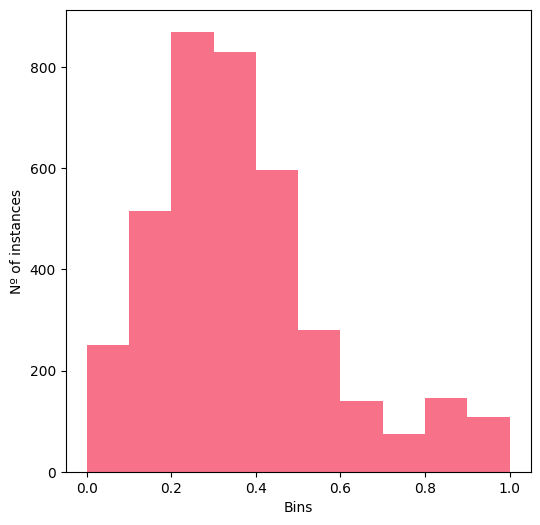

In [20]:
plot_inst_per_bin(iou_assessor_results["GT"])

/tmp/ipykernel_94681/1827797893.py:16: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


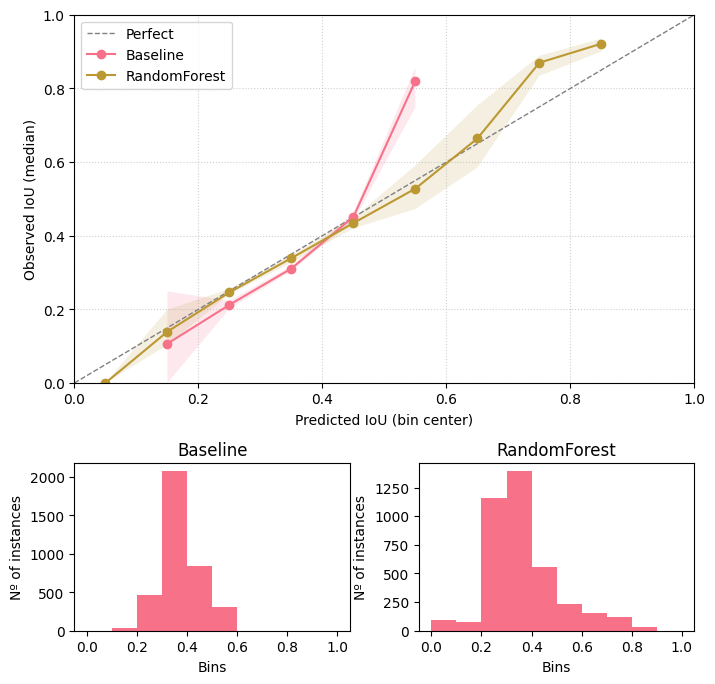

In [21]:
fig = plt.figure(figsize=(8, 8))
gs = GridSpec(2, 2, height_ratios=[2.2, 1], hspace=0.3, wspace=0.25)
ax_cal = fig.add_subplot(gs[0, :])

plot_calibration_curve(iou_assessor_results["GT"],iou_assessor_results["baseline"],ax=ax_cal,label="Baseline")
plot_calibration_curve(iou_assessor_results["GT"],iou_assessor_results["rf"],ax=ax_cal,label="RandomForest", iden_line=False)
ax_cal.legend()

ax_baseline = fig.add_subplot(gs[1, 0])
plot_inst_per_bin(iou_assessor_results["baseline"], ax=ax_baseline)
ax_baseline.set_title("Baseline")
ax_rf = fig.add_subplot(gs[1, 1])
plot_inst_per_bin(iou_assessor_results["rf"], ax=ax_rf)
ax_rf.set_title("RandomForest")

plt.tight_layout()
plt.savefig("./plots/iou_baseline_vs_rf_calib_curve.png")
plt.show()

## LRP

/tmp/ipykernel_94681/2878598436.py:16: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


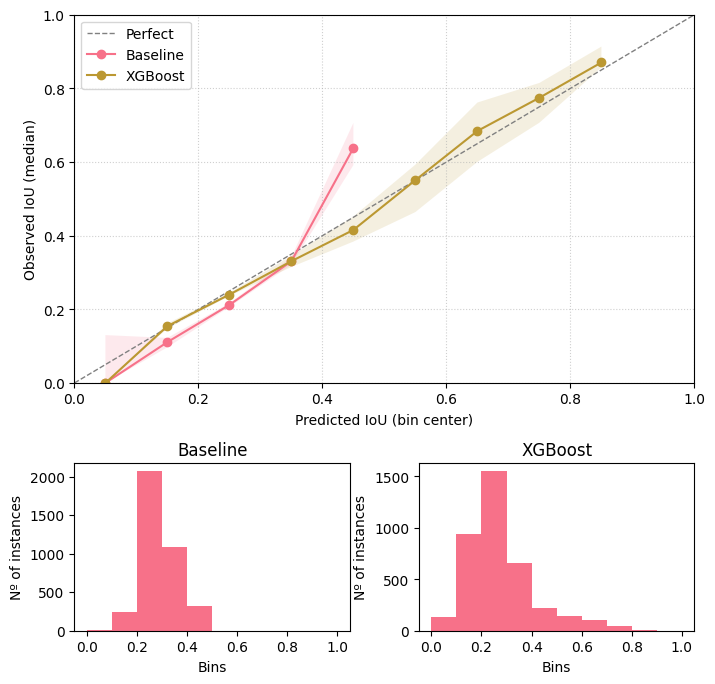

In [22]:

fig = plt.figure(figsize=(8, 8))
gs = GridSpec(2, 2, height_ratios=[2.2, 1], hspace=0.3, wspace=0.25)
ax_cal = fig.add_subplot(gs[0, :])

plot_calibration_curve(lrp_assessor_results["GT"],lrp_assessor_results["baseline"],ax=ax_cal,label="Baseline")
plot_calibration_curve(lrp_assessor_results["GT"],lrp_assessor_results["xgb"],ax=ax_cal,label="XGBoost", iden_line=False)
ax_cal.legend()

ax_baseline = fig.add_subplot(gs[1, 0])
plot_inst_per_bin(lrp_assessor_results["baseline"], ax=ax_baseline)
ax_baseline.set_title("Baseline")
ax_xgb = fig.add_subplot(gs[1, 1])
plot_inst_per_bin(lrp_assessor_results["xgb"], ax=ax_xgb)
ax_xgb.set_title("XGBoost")

plt.tight_layout()
plt.savefig("./plots/lrp_baseline_vs_xgb_calib_curve.png")
plt.show()

# AUROC

For the AUROC we need to discretize the task to binary by setting a treshold. This is not ideal as we are deleting information. So not very useful. 

In [23]:
def plot_auroc(y_true_iou, y_pred, threshold=0.5, ax=None, label=None):
    y_true_iou = np.asarray(y_true_iou)
    y_pred = np.asarray(y_pred)
    success = (y_true_iou > threshold).astype(int)

    fpr, tpr, _ = roc_curve(success, y_pred)
    roc_auc = auc(fpr, tpr)

    if ax is None:
        _, ax = plt.subplots(figsize=(6, 6))

    ax.plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1, label='Random')
    ax.plot(fpr, tpr, label=label or f'AUROC = {roc_auc:.3f}')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend()
    return ax, roc_auc

## IoU

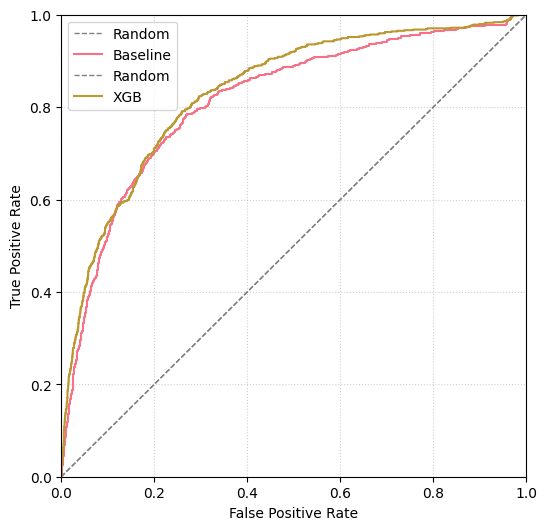

In [24]:
fig, ax = plt.subplots(figsize=(6, 6))
_, roc_auc = plot_auroc(iou_assessor_results["GT"], iou_assessor_results["baseline"], threshold=0.5, ax=ax, label="Baseline")
_, roc_auc = plot_auroc(iou_assessor_results["GT"], iou_assessor_results["xgb"], threshold=0.5, ax=ax, label="XGB")
ax.legend()